# ANTARES / LSST Alert Distribution Comparison

Compares alert distributions from the [ANTARES](https://antares.noirlab.edu) broker across **two MJD time ranges**:
- **Range 1** - Last night: a snapshot of what LSST observed most recently
- **Range 2** - Full LSST history: the cumulative population of all LSST-observed objects

All heavy lifting (queries, lightcurve fetching, caching, plotting, validation) lives in the `src/` package. This notebook is a thin storyboard that wires those helpers together.

Visualisations produced (in later cells):
1. Sky distribution - Aitoff projection (equatorial)
2. Sky density - RA/Dec 2-D histogram
3. Magnitude histograms - 15 < mag < 25, log-scale y-axis, per ZTF filter (g / r / i)

> **MJD rule**: if MJDmin > MJDmax for either range, that range is skipped and nothing is plotted for it.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Install dependencies (Colab; harmless to re-run locally)

In [16]:
!pip install --quiet antares-client elasticsearch-dsl astropy matplotlib pandas numpy pyarrow

## 2. Imports and path setup

We add the project root to `sys.path` so `from src import ...` works regardless of where Jupyter was launched from.

In [17]:
import sys
from pathlib import Path

# Project root = parent of this notebook's folder. Inserting it on
# sys.path lets us `from src import ...` whether the notebook is
# launched from the repo root or from inside notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Dark theme matches the colour choices made in src/figures.py.
plt.style.use('dark_background')
%matplotlib inline

from src import config, query, lightcurves, cache, summary, figures, validation

print('Imports complete.')
print(f'  matplotlib {matplotlib.__version__}')
print(f'  pandas     {pd.__version__}')
print(f'  numpy      {np.__version__}')

Imports complete.
  matplotlib 3.10.0
  pandas     2.2.2
  numpy      2.0.2


## 3. Configuration

All knobs live in `src/config.py`. Edit there to change MJD windows, sample size, tag filter, or the random seed.

In [18]:
config.print_config_summary()

Configuration
  Last Night: MJD 61102.0 - 61103.0  (1.0 days)  [OK]
  LSST History: MJD 60200.0 - 61102.0  (902.0 days)  [OK]
  Samples per range : 5000
  Tag filter        : none (all alerts)
  Random seed       : 42

  Ranges are NON-overlapping  (MJD2_MAX=61102.0, MJD1_MIN=61102.0)


## 4. Validate MJD ranges

If `MJDmin > MJDmax` for a range it is marked invalid and silently skipped by every downstream step.

In [19]:
print('MJD Validation')
print('=' * 55)
RANGE1_VALID = config.validate_mjd_range(config.LABEL1, config.MJD1_MIN, config.MJD1_MAX)
RANGE2_VALID = config.validate_mjd_range(config.LABEL2, config.MJD2_MIN, config.MJD2_MAX)

if not RANGE1_VALID and not RANGE2_VALID:
    raise ValueError('Both MJD ranges are invalid. Edit MJD1/MJD2 in src/config.py.')

MJD Validation
  [Last Night]  2026-03-03  ->  2026-03-04  (1.0 days)
  [LSST History]  2023-09-13  ->  2026-03-03  (902.0 days)


## 5. Cache check

If a previous run produced parquet files for the SAME parameters, load from disk and skip ANTARES entirely. Cache files are keyed by MJD bounds and `N_SAMPLES`, so any config change naturally invalidates them.

In [20]:
USE_CACHE = True   # load from cache if available
SAVE_CACHE = True  # write cache after a live fetch

# Keep cache files alongside data/ so the repo root stays tidy.
CACHE_DIR = str(PROJECT_ROOT / 'data')
Path(CACHE_DIR).mkdir(exist_ok=True)

_paths = cache.cache_paths(
    CACHE_DIR,
    config.MJD1_MIN, config.MJD1_MAX,
    config.MJD2_MIN, config.MJD2_MAX,
    config.N_SAMPLES,
)
_CACHE_LOADED, df1, df2, df1_alerts, df2_alerts = cache.try_load_cache(
    _paths, config.LABEL1, config.LABEL2, use_cache=USE_CACHE,
)

Cache found - loading from disk (ANTARES queries skipped)
  Last Night          :  5000 loci,  1,191,625 alert rows
  LSST History        :  5000 loci,  432,741 alert rows
  Loaded in 7.94s
  To force a fresh query: delete cache_*.parquet files or set USE_CACHE = False.


## 6. Run ANTARES queries (skipped if loaded from cache)

Both queries are independent network calls, so we run them in parallel via `query.query_both_ranges_parallel` for ~2x wall-clock speedup.

In [21]:
if _CACHE_LOADED:
    print('Queries: skipped (data loaded from cache).')
else:
    print('Loading locus-level data (no lightcurves - fast)')
    print('=' * 55)

    # Build per-range kwargs; pass None to skip an invalid range entirely.
    r1_args = dict(
        label=config.LABEL1, mjd_min=config.MJD1_MIN, mjd_max=config.MJD1_MAX,
        n_samples=config.N_SAMPLES, tag=config.QUERY_TAG, seed=config.RANDOM_SEED,
    ) if RANGE1_VALID else None
    r2_args = dict(
        label=config.LABEL2, mjd_min=config.MJD2_MIN, mjd_max=config.MJD2_MAX,
        n_samples=config.N_SAMPLES, tag=config.QUERY_TAG, seed=config.RANDOM_SEED,
    ) if RANGE2_VALID else None

    df1, df2 = query.query_both_ranges_parallel(r1_args, r2_args)
    print(f'  {config.LABEL1:20s}: {len(df1):>5d} loci')
    print(f'  {config.LABEL2:20s}: {len(df2):>5d} loci')

Queries: skipped (data loaded from cache).


## 7. Load lightcurves (per-alert photometry)

Each lightcurve is one HTTP request, so we use a thread pool. Set `LOAD_LIGHTCURVES = False` to skip and fall back to locus-level magnitudes.

In [22]:
LOAD_LIGHTCURVES = True
N_LC_SAMPLES = 5000  # lightcurves to fetch per range

if _CACHE_LOADED:
    print('Lightcurves: skipped (data loaded from cache).')
elif LOAD_LIGHTCURVES:
    print('Loading lightcurves (per-alert data)')
    print('=' * 55)
    df1_alerts = lightcurves.load_lightcurves(df1, N_LC_SAMPLES, config.LABEL1)
    df2_alerts = lightcurves.load_lightcurves(df2, N_LC_SAMPLES, config.LABEL2)
else:
    print('Lightcurve loading skipped (LOAD_LIGHTCURVES = False).')
    print('Magnitude histograms will use locus-level brightest_alert_magnitude.')

Lightcurves: skipped (data loaded from cache).


## 8. Save cache (only after a fresh fetch)

In [23]:
if not _CACHE_LOADED and SAVE_CACHE:
    cache.save_cache(_paths, df1, df2, df1_alerts, df2_alerts)
elif _CACHE_LOADED:
    print('Cache was used - no save needed.')

Cache was used - no save needed.


## 9. Summary statistics

In [24]:
summary.print_all_summaries(
    config.LABEL1, df1, df1_alerts,
    config.LABEL2, df2, df2_alerts,
)

DATA SUMMARY

  Last Night
  Loci loaded        :  5,000
  RA  range          : 57.21 deg - 192.34 deg
  Dec range          : -27.96 deg - 37.03 deg
  Newest obs (MJD): 61102.26 - 61102.31  (median 61102.28)
  Brightest mag   : 10.33 - 19.66  (median 17.21)
  Obs count       : 1.00 - 1194.00  (median 2.00)
  Alert rows         : 1,191,625
  Locus columns      : 219 total

  LSST History
  Loci loaded        :  5,000
  RA  range          : 252.74 deg - 328.13 deg
  Dec range          : -9.06 deg - 33.44 deg
  Newest obs (MJD): 61101.55 - 61101.56  (median 61101.56)
  Brightest mag   : 12.60 - 18.78  (median 16.17)
  Obs count       : 1.00 - 1250.00  (median 3.00)
  Alert rows         : 432,741
  Locus columns      : 199 total


## 10. Plot 1 - Sky distribution (Aitoff)

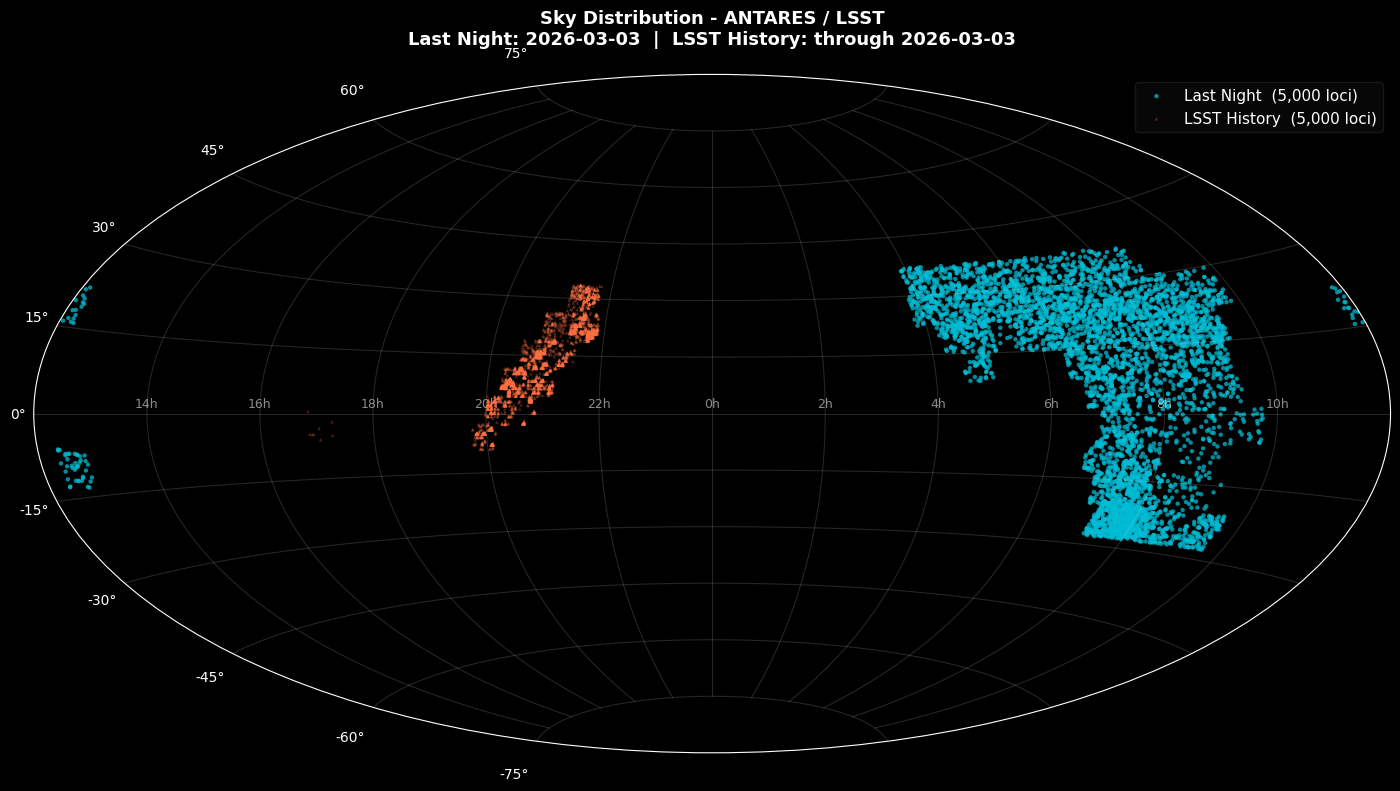

In [25]:
figures.plot_sky_aitoff(
    df1, df2, RANGE1_VALID, RANGE2_VALID,
    config.LABEL1, config.LABEL2,
    config.MJD1_MIN, config.MJD2_MAX,
);

## 11. Plot 2 - Sky density (2-D RA/Dec histogram)

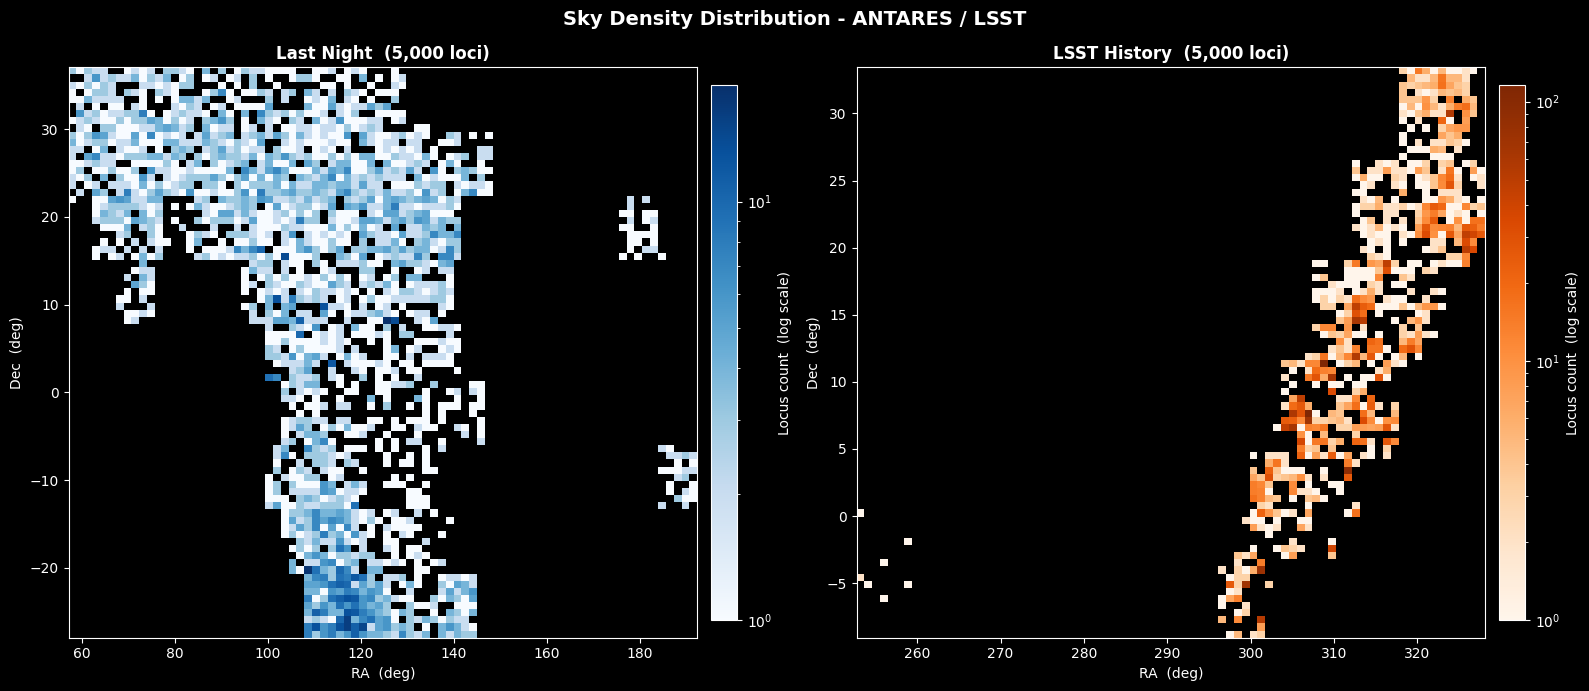

In [26]:
figures.plot_sky_density(
    df1, df2, RANGE1_VALID, RANGE2_VALID,
    config.LABEL1, config.LABEL2,
);

## 12. Plot 3 - Magnitude histograms

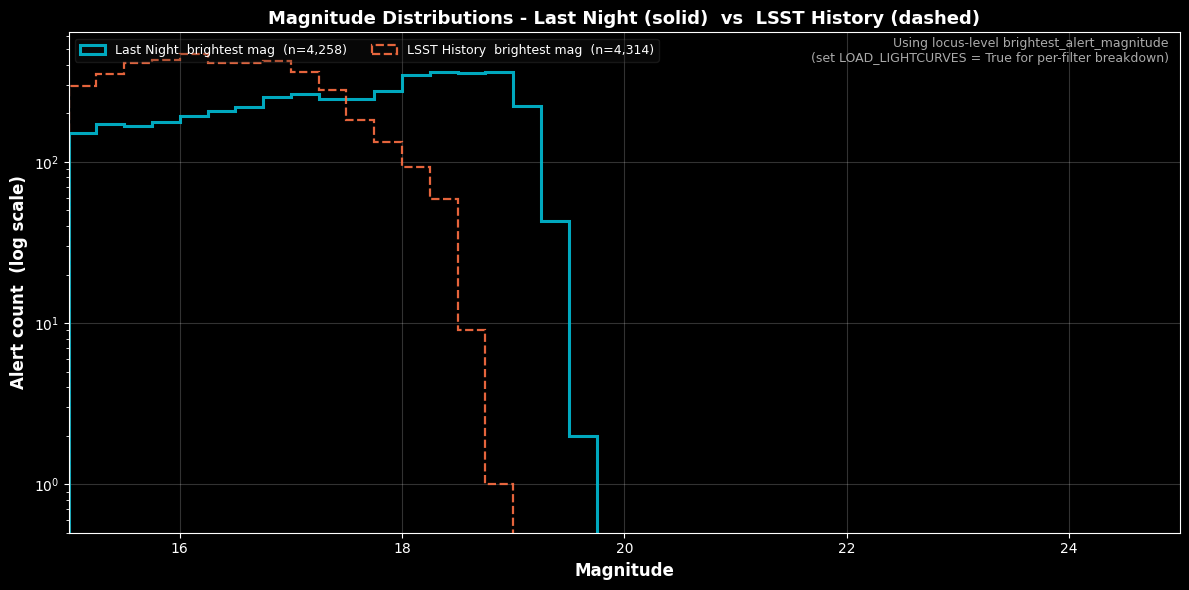

In [27]:
figures.plot_magnitude_histograms(
    df1, df2, df1_alerts, df2_alerts,
    RANGE1_VALID, RANGE2_VALID,
    config.LABEL1, config.LABEL2,
);

## 13. Validation suite

Eight numbered tests covering data presence, MJD compliance, coordinate sanity, LSST-era origin, magnitude window coverage, locus uniqueness, cross-range overlap (a critical randomisation check), and the MJDmin/MJDmax guard.

In [28]:
validation.run_validation_suite(
    df1, df2, df1_alerts, df2_alerts,
    RANGE1_VALID, RANGE2_VALID,
    config.LABEL1, config.LABEL2,
    config.MJD1_MIN, config.MJD1_MAX,
    config.MJD2_MIN, config.MJD2_MAX,
);

  ANTARES / LSST DATA VALIDATION

[1] Data retrieval
  [PASS]  Last Night: at least 1 locus retrieved  (got 5000)
  [PASS]  LSST History: at least 1 locus retrieved  (got 5000)

[2] MJD compliance  (newest_alert_observation_time within queried window)
  [PASS]  Last Night: all 5000 MJDs within [61102.0, 61103.0]
          MJD actual range: 61102.259 - 61102.314
  [PASS]  LSST History: all 5000 MJDs within [60200.0, 61102.0]
          MJD actual range: 61101.551 - 61101.562

[3] Coordinate validity  (0 <= RA < 360 deg,  -90 <= Dec <= 90 deg)
  [PASS]  Last Night: RA  valid  (0 bad)
  [PASS]  Last Night: Dec valid  (0 bad)
  [PASS]  LSST History: RA  valid  (0 bad)
  [PASS]  LSST History: Dec valid  (0 bad)

[4] LSST-era verification  (obs time >= MJD 60200.0)
  [PASS]  Last Night: >=95% of loci in LSST era  (0 pre-LSST of 5000)
  [PASS]  LSST History: >=95% of loci in LSST era  (0 pre-LSST of 5000)
  [INFO]  No lsst_*/rubin_* columns found; data is ZTF-origin processed during the LSST e